# Notebook 01 — Exploratory Data Analysis
**Project:** Vendor Risk Scorecard & Delivery Delay Root Cause System  
**Dataset:** Olist Brazilian E-commerce (Kaggle)  
**Goal:** Understand the data structure, check quality, and identify key columns for analysis.

---
### What we do in this notebook
1. Mount Google Drive and set up paths
2. Load the 5 relevant CSVs
3. Understand what each table contains
4. Check nulls, data types, and anomalies
5. Calculate the 3 core delivery time intervals
6. Explore distributions and geographic patterns
7. Save a clean merged base table back to Drive

---
## Cell 1 — Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')
print('Drive mounted')

Mounted at /content/drive
Drive mounted


---
## Cell 2 — Imports and paths


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

BASE    = '/content/drive/MyDrive/vendor-risk-scorecard/'
RAW     = BASE + 'data/raw/'
PROC    = BASE + 'data/processed/'
OUTPUTS = BASE + 'outputs/'


os.makedirs(PROC,    exist_ok=True)
os.makedirs(OUTPUTS, exist_ok=True)


sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.titlesize'] = 13

print('Imports done')
print(f'Looking for data in: {RAW}')

Imports done
Looking for data in: /content/drive/MyDrive/vendor-risk-scorecard/data/raw/


---
## Cell 3 — Verifying files are in the right place

In [3]:
files = os.listdir(RAW)
print(f'Files found in raw folder ({len(files)} total):')
for f in sorted(files):
    print(f'  {f}')

Files found in raw folder (9 total):
  olist_customers_dataset.csv
  olist_geolocation_dataset.csv
  olist_order_items_dataset.csv
  olist_order_payments_dataset.csv
  olist_order_reviews_dataset.csv
  olist_orders_dataset.csv
  olist_products_dataset.csv
  olist_sellers_dataset.csv
  product_category_name_translation.csv


---
## Cell 4 — Loading the 5 tables we need

We only need 5 of the 9 CSVs.


In [4]:
orders      = pd.read_csv(RAW + 'olist_orders_dataset.csv')
order_items = pd.read_csv(RAW + 'olist_order_items_dataset.csv')
sellers     = pd.read_csv(RAW + 'olist_sellers_dataset.csv')
customers   = pd.read_csv(RAW + 'olist_customers_dataset.csv')
geo         = pd.read_csv(RAW + 'olist_geolocation_dataset.csv')

print('Loaded successfully:')
for name, df in [('orders', orders), ('order_items', order_items),
                 ('sellers', sellers), ('customers', customers), ('geo', geo)]:
    print(f'  {name:15s} → {df.shape[0]:>7,} rows  {df.shape[1]:>2} cols')

Loaded successfully:
  orders          →  99,441 rows   8 cols
  order_items     → 112,650 rows   7 cols
  sellers         →   3,095 rows   4 cols
  customers       →  99,441 rows   5 cols
  geo             → 1,000,163 rows   5 cols


---
## Cell 5 — Orders table

- **seller_days** = how long the seller took to pack and hand over
- **carrier_days** = how long the carrier took to deliver once they had it
- **delay_days** = positive means late, negative means early

In [5]:
print('Orders columns:')
for col in orders.columns:
    print(f'  {col}')

Orders columns:
  order_id
  customer_id
  order_status
  order_purchase_timestamp
  order_approved_at
  order_delivered_carrier_date
  order_delivered_customer_date
  order_estimated_delivery_date


In [6]:
# Order status breakdown — we only want DELIVERED orders
print('Order status counts:')
print(orders['order_status'].value_counts().to_string())
print()
delivered_count = (orders['order_status'] == 'delivered').sum()
print(f'Delivered orders: {delivered_count:,} out of {len(orders):,} total ({delivered_count/len(orders)*100:.1f}%)')

Order status counts:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2

Delivered orders: 96,478 out of 99,441 total (97.0%)


In [7]:
# Checking nulls in the 5 timestamp columns
ts_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
print('Null counts in timestamp columns:')
print(orders[ts_cols].isnull().sum().to_string())
print()
print('Order_delivered_carrier_date nulls = seller never handed to carrier (cancelled/lost)')
print('Order_delivered_customer_date nulls = not yet delivered (we filter these out)')

Null counts in timestamp columns:
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0

Order_delivered_carrier_date nulls = seller never handed to carrier (cancelled/lost)
Order_delivered_customer_date nulls = not yet delivered (we filter these out)


---
## Cell 6 — Filter and parse timestamps

In [8]:
df = orders[orders['order_status'] == 'delivered'].copy()
print(f'Working with {len(df):,} delivered orders')

for col in ts_cols:
    df[col] = pd.to_datetime(df[col])

print('Timestamps parsed')

Working with 96,478 delivered orders
Timestamps parsed


---
## Cell 7 — Calculating the 3 core delivery intervals

In [9]:
# 1. Seller processing time: how long from purchase until seller handed to carrier
df['seller_processing_days'] = (
    df['order_delivered_carrier_date'] - df['order_purchase_timestamp']
).dt.total_seconds() / 86400   # convert seconds → days

# 2. Carrier delivery time: how long from carrier pickup to customer delivery
df['carrier_delivery_days'] = (
    df['order_delivered_customer_date'] - df['order_delivered_carrier_date']
).dt.total_seconds() / 86400

# 3. Delay vs estimate: positive = late, negative = early
df['delay_days'] = (
    df['order_delivered_customer_date'] - df['order_estimated_delivery_date']
).dt.total_seconds() / 86400

# 4. Binary flag: was it late?
df['is_late'] = df['delay_days'] > 0

print('Interval statistics (days):')
print(df[['seller_processing_days', 'carrier_delivery_days', 'delay_days']].describe().round(2))

Interval statistics (days):
       seller_processing_days  carrier_delivery_days  delay_days
count                96476.00               96469.00    96470.00
mean                     3.23                   9.33      -11.18
std                      3.60                   8.76       10.18
min                   -171.21                 -16.10     -146.02
25%                      1.13                   4.10      -16.24
50%                      2.20                   7.10      -11.95
75%                      4.07                  12.03       -6.39
max                    125.78                 205.19      188.98


In [10]:
late_pct = df['is_late'].mean() * 100
print(f'  OVERALL LATE RATE: {late_pct:.1f}%')
print(f'  Late orders:       {df["is_late"].sum():,}')
print(f'  On-time orders:    {(~df["is_late"]).sum():,}')

  OVERALL LATE RATE: 8.1%
  Late orders:       7,826
  On-time orders:    88,652


---
## Cell 8 — Visualising the 3 intervals

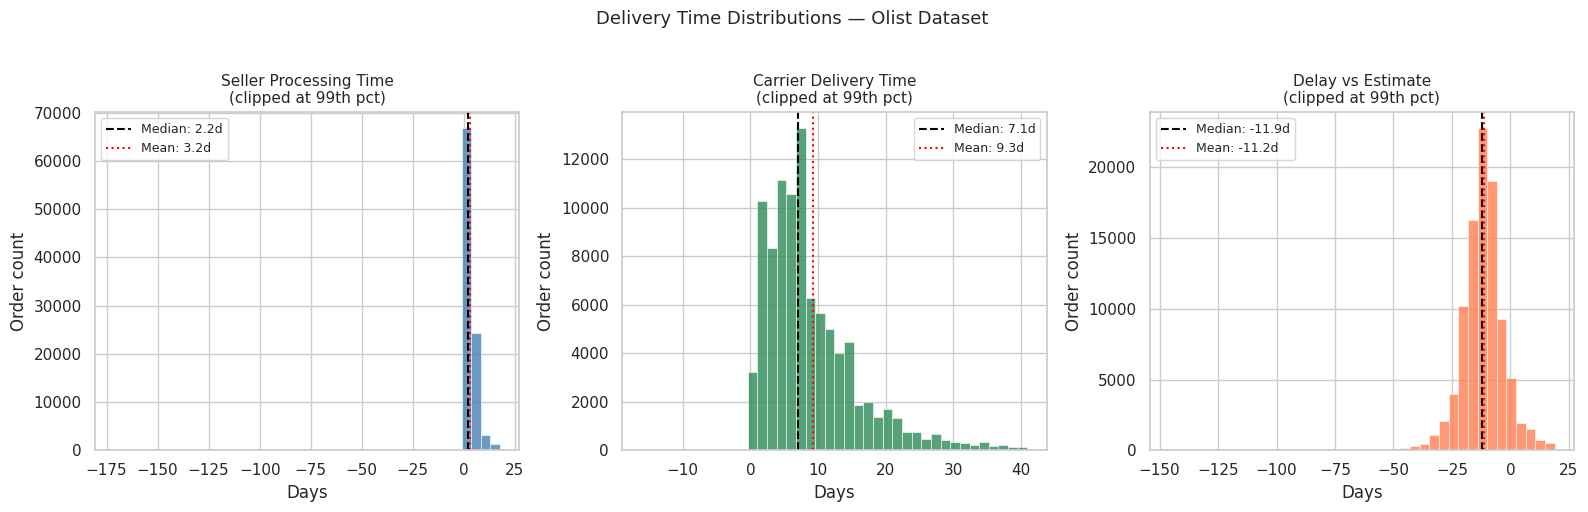

Saved to outputs/ 


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

configs = [
    ('seller_processing_days', 'Seller Processing Time',  'steelblue'),
    ('carrier_delivery_days',  'Carrier Delivery Time',   'seagreen'),
    ('delay_days',             'Delay vs Estimate',       'coral'),
]

for ax, (col, title, color) in zip(axes, configs):
    data = df[col].dropna()
    # Clip at 99th percentile to remove extreme outliers from the chart
    clipped = data[data <= data.quantile(0.99)]
    ax.hist(clipped, bins=40, color=color, alpha=0.8, edgecolor='white', linewidth=0.5)
    ax.axvline(data.median(), color='black', linestyle='--', lw=1.5,
               label=f'Median: {data.median():.1f}d')
    ax.axvline(data.mean(), color='red', linestyle=':', lw=1.5,
               label=f'Mean: {data.mean():.1f}d')
    ax.set_title(f'{title}\n(clipped at 99th pct)', fontsize=11)
    ax.set_xlabel('Days')
    ax.set_ylabel('Order count')
    ax.legend(fontsize=9)

plt.suptitle('Delivery Time Distributions — Olist Dataset', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUTS + '01_delivery_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to outputs/ ')

**What to look for in these charts:**
- Seller processing time: Is it right-skewed? (Most sellers are fast, a few are very slow)
- Carrier delivery time: Is it wider spread? (Geography affects this)
- Delay days: Where is the peak relative to 0? Lots of negative values = Amazon-style buffer padding on estimates

---
## Cell 9 — Merge seller and customer data

In [12]:
# Join order_items to get seller_id per order
items_primary = (
    order_items
    .sort_values('order_item_id')
    .groupby('order_id')
    .first()
    .reset_index()[['order_id', 'seller_id', 'price']]
)

df = df.merge(items_primary, on='order_id', how='left')
print(f'After adding seller_id: {df.shape}')

# Add seller state
df = df.merge(
    sellers[['seller_id', 'seller_zip_code_prefix', 'seller_state']],
    on='seller_id', how='left'
)

# Add customer state
df = df.merge(
    customers[['customer_id', 'customer_zip_code_prefix', 'customer_state']],
    on='customer_id', how='left'
)

print(f'After adding states: {df.shape}')

After adding seller_id: (96478, 14)
After adding states: (96478, 18)


In [13]:
# Dropping rows where critical columns are null
critical = ['seller_id', 'seller_processing_days',
            'carrier_delivery_days', 'delay_days',
            'seller_state', 'customer_state']

before = len(df)
df = df.dropna(subset=critical)
after  = len(df)

print(f'Rows before cleaning: {before:,}')
print(f'Rows after cleaning:  {after:,}')
print(f'Dropped:              {before - after:,} ({(before-after)/before*100:.1f}%)')

Rows before cleaning: 96,478
Rows after cleaning:  96,469
Dropped:              9 (0.0%)


---
## Cell 10 — Geographic late rate analysis

In [14]:
# How many unique sellers?
print(f'Unique sellers in dataset: {df["seller_id"].nunique():,}')

# Orders per seller distribution
orders_per_seller = df.groupby('seller_id')['order_id'].count()
print(f'\nOrders per seller:')
print(orders_per_seller.describe().round(1))
print(f'\nSellers with < 5 orders: {(orders_per_seller < 5).sum():,} (will exclude from scoring — too few to be reliable)')

Unique sellers in dataset: 2,960

Orders per seller:
count    2960.0
mean       32.6
std       104.4
min         1.0
25%         2.0
50%         7.0
75%        22.0
max      1809.0
Name: order_id, dtype: float64

Sellers with < 5 orders: 1,204 (will exclude from scoring — too few to be reliable)


In [15]:
# Late rate by SELLER state
seller_state_stats = (
    df.groupby('seller_state')
    .agg(
        total_orders   = ('order_id', 'count'),
        late_orders    = ('is_late', 'sum'),
        avg_seller_days= ('seller_processing_days', 'mean'),
        avg_delay      = ('delay_days', 'mean')
    )
    .reset_index()
)
seller_state_stats['late_rate_%'] = (
    seller_state_stats['late_orders'] / seller_state_stats['total_orders'] * 100
).round(1)
seller_state_stats = seller_state_stats.sort_values('late_rate_%', ascending=False)

print('Top 10 seller states by late delivery rate:')
print(seller_state_stats.head(10).to_string(index=False))

Top 10 seller states by late delivery rate:
seller_state  total_orders  late_orders  avg_seller_days  avg_delay  late_rate_%
          AM             3            2         3.430004   9.347431         66.7
          MA           388           90         4.844455 -10.614126         23.2
          PA             8            1         3.472717 -10.573477         12.5
          RN            51            5         4.400399 -12.810724          9.8
          CE            85            8         3.266450 -12.579922          9.4
          SP         68415         6001         3.233746 -10.426179          8.8
          MS            47            4         4.193959 -16.641382          8.5
          RJ          4185          354         2.841128 -11.708157          8.5
          ES           308           22         2.550547 -12.387184          7.1
          PR          7428          484         3.453234 -13.385656          6.5


In [16]:
# Late rate by CUSTOMER state
cust_state_stats = (
    df.groupby('customer_state')
    .agg(
        total_orders = ('order_id', 'count'),
        late_orders  = ('is_late', 'sum'),
        avg_delay    = ('delay_days', 'mean')
    )
    .reset_index()
)
cust_state_stats['late_rate_%'] = (
    cust_state_stats['late_orders'] / cust_state_stats['total_orders'] * 100
).round(1)
cust_state_stats = cust_state_stats.sort_values('late_rate_%', ascending=False)

print('Top 10 customer states by late delivery rate:')
print(cust_state_stats.head(10).to_string(index=False))

Top 10 customer states by late delivery rate:
customer_state  total_orders  late_orders  avg_delay  late_rate_%
            AL           397           95  -8.032059         23.9
            MA           717          141  -8.887844         19.7
            PI           476           76 -10.629538         16.0
            CE          1279          196 -10.110007         15.3
            SE           335           51  -9.328641         15.2
            BA          3256          457 -10.099073         14.0
            RJ         12350         1664 -11.054735         13.5
            TO           274           35 -11.439738         12.8
            PA           946          117 -13.386288         12.4
            RR            41            5 -16.594598         12.2


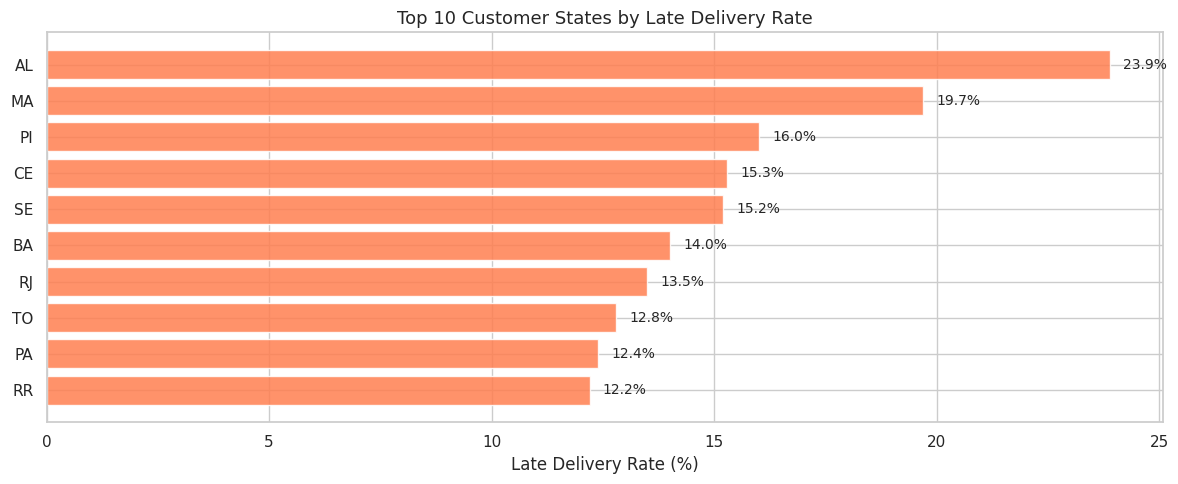

Saved


In [17]:
# Bar chart — top 10 customer states by late rate
top10 = cust_state_stats.head(10)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(top10['customer_state'][::-1], top10['late_rate_%'][::-1],
               color='coral', alpha=0.85, edgecolor='white')
ax.set_xlabel('Late Delivery Rate (%)')
ax.set_title('Top 10 Customer States by Late Delivery Rate')

# Add value labels
for bar, val in zip(bars, top10['late_rate_%'][::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10)

plt.tight_layout()
plt.savefig(OUTPUTS + '01_customer_state_late_rates.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved')

---
## Cell 11 — Seller volume distribution

We need to know how many orders each seller has. Sellers with very few orders will give unreliable metrics — we'll exclude them from scoring in notebook 04.

In [18]:
orders_per_seller = df.groupby('seller_id')['order_id'].count().sort_values(ascending=False)

print('Seller order volume distribution:')
print(orders_per_seller.describe().round(1))
print()

# How many sellers have enough orders to score reliably?
MIN_ORDERS = 10   # our threshold — sellers with < 10 orders get excluded from scoring
eligible = (orders_per_seller >= MIN_ORDERS).sum()
total    = len(orders_per_seller)
print(f'Sellers with >= {MIN_ORDERS} orders (eligible for scoring): {eligible:,} of {total:,} ({eligible/total*100:.1f}%)')
print(f'These {eligible:,} sellers cover {(orders_per_seller[orders_per_seller >= MIN_ORDERS].sum()):,} orders')

Seller order volume distribution:
count    2960.0
mean       32.6
std       104.4
min         1.0
25%         2.0
50%         7.0
75%        22.0
max      1809.0
Name: order_id, dtype: float64

Sellers with >= 10 orders (eligible for scoring): 1,226 of 2,960 (41.4%)
These 1,226 sellers cover 90,511 orders


---
## Cell 12 — Save clean base dataset to Drive

In [19]:
keep_cols = [
    'order_id', 'customer_id', 'seller_id',
    'order_purchase_timestamp',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'seller_processing_days',
    'carrier_delivery_days',
    'delay_days',
    'is_late',
    'price',
    'seller_state', 'seller_zip_code_prefix',
    'customer_state', 'customer_zip_code_prefix'
]

df_clean = df[keep_cols].copy()
df_clean.to_csv(PROC + 'orders_clean.csv', index=False)

print(f'Saved: orders_clean.csv')
print(f'Shape: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns')
print()
print('Preview:')
df_clean.head(3)

Saved: orders_clean.csv
Shape: 96,469 rows × 16 columns

Preview:


,order_id,customer_id,seller_id,order_purchase_timestamp,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,seller_processing_days,carrier_delivery_days,delay_days,is_late,price,seller_state,seller_zip_code_prefix,customer_state,customer_zip_code_prefix
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-02 10:56:33,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2.373924,6.062650,-7.107488,False,29.99,SP,9350,SP,3149
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,289cdb325fb7e7f891c38608bf9e0962,2018-07-24 20:41:37,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1.742627,12.039410,-5.355729,False,118.70,SP,31570,BA,47813
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-08 08:38:49,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,0.216100,9.178113,-17.245498,False,159.90,SP,14840,GO,75265


---
## EDA Summary

| Metric | Value |
|---|---|
| Total delivered orders | 96478 |
| Overall late rate % | 8.1% |
| Median seller processing time | 2.20|
| Median carrier delivery time | 7.10|
| Unique sellers total | 2960  |
| Sellers eligible for scoring (≥10 orders) | 1227 |
| Highest late-rate customer state | 23.9% |
| Highest late-rate seller state | 66.7% |

